# 02 — Onset Engine Development
**ROPIAS Project — KCA University**

This notebook builds and validates the True/False onset detection engine
using real NASA POWER data from 2022 (a known false onset year for Western Kenya).

---

## Step 1: Fetch real data (same as notebook 01)

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fetch 90 days to get a proper validation window
url = 'https://power.larc.nasa.gov/api/temporal/daily/point'
params = {
    'parameters': 'PRECTOTCORR,GWETROOT',
    'community': 'AG',
    'longitude': 34.75,
    'latitude': 0.28,
    'start': '20220201',
    'end': '20220531',
    'format': 'JSON'
}

response = requests.get(url, params=params, timeout=15)
data = response.json()
params_data = data['properties']['parameter']

rainfall = pd.Series(params_data['PRECTOTCORR'])
rainfall.index = pd.to_datetime(rainfall.index, format='%Y%m%d')
rainfall = rainfall.replace(-999.0, 0.0)

soil = pd.Series(params_data['GWETROOT'])
soil.index = pd.to_datetime(soil.index, format='%Y%m%d')
soil = soil.replace(-999.0, float('nan'))

print(f'Fetched {len(rainfall)} days of data')
print(f'Range: {rainfall.index[0].date()} to {rainfall.index[-1].date()}')

Fetched 120 days of data
Range: 2022-02-01 to 2022-05-31


## Step 2: Implement and test the dry spell detector

In [3]:
def detect_dry_spell(rain_series, threshold_mm=1.0, consecutive_days=7):
    """Returns True if a 7+ day dry spell exists in the series."""
    consecutive = 0
    for value in rain_series:
        if pd.isna(value) or float(value) < threshold_mm:
            consecutive += 1
            if consecutive >= consecutive_days:
                return True
        else:
            consecutive = 0
    return False

# Quick tests with known data
test_with_dry_spell    = pd.Series([5, 5, 0, 0, 0, 0, 0, 0, 0, 5])
test_without_dry_spell = pd.Series([5, 5, 3, 2, 1, 4, 5, 2, 3, 1])

print('Test 1 (has 7 dry days) - should be True: ', detect_dry_spell(test_with_dry_spell))
print('Test 2 (no dry spell)   - should be False:', detect_dry_spell(test_without_dry_spell))

Test 1 (has 7 dry days) - should be True:  True
Test 2 (no dry spell)   - should be False: False


## Step 3: Find all onset candidates in 2022 data

In [4]:
THRESHOLD_MM = 20.0
WINDOW_DAYS  = 2

# Rolling 2-day cumulative sum
rolling_2day = rainfall.rolling(window=WINDOW_DAYS, min_periods=1).sum()

# Find candidate dates
candidates = rolling_2day[rolling_2day >= THRESHOLD_MM]

print(f'Onset candidates found: {len(candidates)}')
print()
for date, val in candidates.items():
    print(f'  {date.date()}: {val:.2f}mm cumulative (2-day)')

Onset candidates found: 18

  2022-03-29: 21.06mm cumulative (2-day)
  2022-04-01: 20.82mm cumulative (2-day)
  2022-04-22: 36.78mm cumulative (2-day)
  2022-04-23: 29.70mm cumulative (2-day)
  2022-04-26: 27.14mm cumulative (2-day)
  2022-04-27: 47.05mm cumulative (2-day)
  2022-04-28: 34.50mm cumulative (2-day)
  2022-05-02: 20.70mm cumulative (2-day)
  2022-05-06: 25.92mm cumulative (2-day)
  2022-05-07: 27.19mm cumulative (2-day)
  2022-05-18: 36.94mm cumulative (2-day)
  2022-05-19: 49.91mm cumulative (2-day)
  2022-05-22: 21.72mm cumulative (2-day)
  2022-05-23: 21.25mm cumulative (2-day)
  2022-05-28: 37.23mm cumulative (2-day)
  2022-05-29: 43.36mm cumulative (2-day)
  2022-05-30: 28.05mm cumulative (2-day)
  2022-05-31: 20.95mm cumulative (2-day)


## Step 4: Validate each candidate — check for dry spell after it

In [5]:
VALIDATION_DAYS = 30

print('=== ONSET VALIDATION RESULTS ===')
print()

for onset_date in reversed(candidates.index):
    validation_end    = onset_date + pd.Timedelta(days=VALIDATION_DAYS)
    validation_window = rainfall[
        (rainfall.index > onset_date) &
        (rainfall.index <= validation_end)
    ]

    dry_spell_found = detect_dry_spell(validation_window)
    classification  = 'FALSE ONSET ❌' if dry_spell_found else 'TRUE ONSET ✅'

    print(f'  Date: {onset_date.date()}')
    print(f'  2-day rain: {candidates[onset_date]:.1f}mm')
    print(f'  Dry spell in next 30 days: {dry_spell_found}')
    print(f'  Classification: {classification}')
    print()
    break  # Take the most recent candidate first

=== ONSET VALIDATION RESULTS ===

  Date: 2022-05-31
  2-day rain: 20.9mm
  Dry spell in next 30 days: False
  Classification: TRUE ONSET ✅



## Step 5: Visualize the full analysis

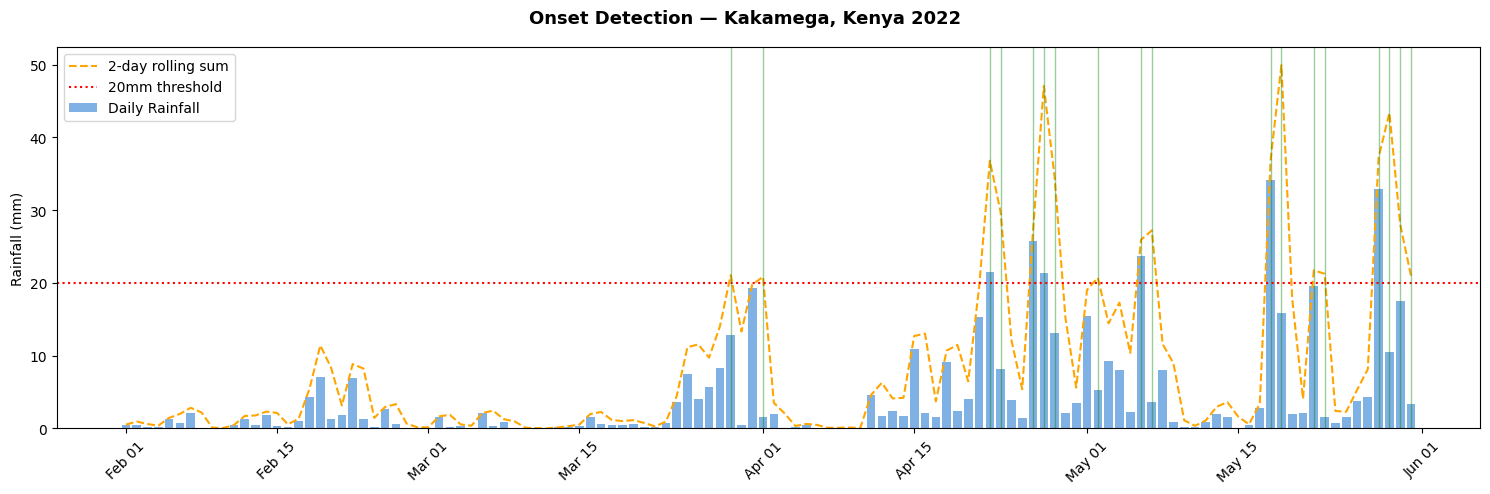

Saved!


In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle('Onset Detection — Kakamega, Kenya 2022', fontsize=13, fontweight='bold')

# Bars
ax.bar(rainfall.index, rainfall.values, color='#4A90D9', width=0.8, alpha=0.7, label='Daily Rainfall')

# Rolling sum line
ax.plot(rainfall.index, rolling_2day.values, color='orange', linewidth=1.5,
        linestyle='--', label='2-day rolling sum')

# Threshold line
ax.axhline(y=20, color='red', linestyle=':', linewidth=1.5, label='20mm threshold')

# Mark candidates
for date in candidates.index:
    ax.axvline(x=date, color='green', alpha=0.4, linewidth=1)

ax.set_ylabel('Rainfall (mm)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('../data/onset_analysis_2022.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')